In [ ]:
import pandas as pd

# I imported pandas for data handling
# I loaded the dataset from the CSV file

df = pd.read_csv("bank-full.csv", sep=";",engine="python")


In [ ]:
# I cleaned the column names by removing extra spaces from the columns.

df.columns = df.columns.str.strip()


In [ ]:
# I renamed the columns to make them more clear and meaningful way so that will be easy for me
df = df.rename(columns={
    "y": "target",
    "job": "job_type",
    "marital": "marital_status",
    "education": "education_level",
    "default": "credit_default",
    "housing": "housing_loan",
    "loan": "personal_loan",
    "contact": "contact_type",
    "duration": "call_duration",
    "campaign": "contact_count",
    "pdays": "days_since_last_contact",
    "previous": "previous_contacts",
    "poutcome": "previous_campaign_outcome"
})


In [ ]:
# I checked the shape of the dataset

print("Dataset shape:", df.shape)


Dataset shape: (45211, 17)


In [ ]:
# I checked how many duplicate rows are there
print("Duplicate rows:", df.duplicated().sum())

# I removed the duplicate rows
df = df.drop_duplicates()

# I checked the shape again after removing duplicates
print("Shape after removing duplicates:", df.shape)


Duplicate rows: 0
Shape after removing duplicates: (45211, 17)


In [ ]:
# I checked null values in each column
print(df.isnull().sum())


age                          0
job_type                     0
marital_status               0
education_level              0
credit_default               0
balance                      0
housing_loan                 0
personal_loan                0
contact_type                 0
day                          0
month                        0
call_duration                0
contact_count                0
days_since_last_contact      0
previous_contacts            0
previous_campaign_outcome    0
target                       0
dtype: int64


In [ ]:
# I calculated the total number of null values
print("Total null values:", df.isnull().sum().sum())


Total null values: 0


In [ ]:
# I converted the target column into binary values
df["target"] = df["target"].map({"yes": 1, "no": 0})


In [ ]:
# I Dropped call duration to avoid data leakage
df = df.drop(columns=["call_duration"])


In [ ]:
# I checked the data types and overall dataset info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        45211 non-null  int64 
 1   job_type                   45211 non-null  object
 2   marital_status             45211 non-null  object
 3   education_level            45211 non-null  object
 4   credit_default             45211 non-null  object
 5   balance                    45211 non-null  int64 
 6   housing_loan               45211 non-null  object
 7   personal_loan              45211 non-null  object
 8   contact_type               45211 non-null  object
 9   day                        45211 non-null  int64 
 10  month                      45211 non-null  object
 11  contact_count              45211 non-null  int64 
 12  days_since_last_contact    45211 non-null  int64 
 13  previous_contacts          45211 non-null  int64 
 14  previo

In [ ]:
# I looked at the summary statistics of numerical columns

df.describe()


,age,balance,day,contact_count,days_since_last_contact,previous_contacts,target
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,2.763841,40.197828,0.580323,0.116985
std,10.618762,3044.765829,8.322476,3.098021,100.128746,2.303441,0.321406
min,18.000000,-8019.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,72.000000,8.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,448.000000,16.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1428.000000,21.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,102127.000000,31.000000,63.000000,871.000000,275.000000,1.000000


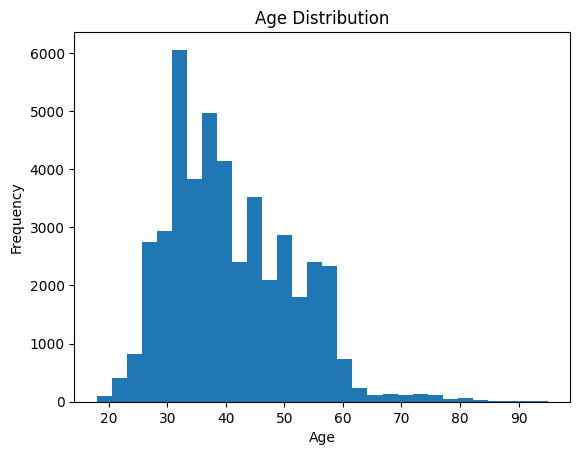

In [ ]:
import matplotlib.pyplot as plt

# I plotted the age distribution using a histogram

plt.hist(df["age"], bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# I checked the count of target classes
df["target"].value_counts()


,count
target,
0,39922
1,5289


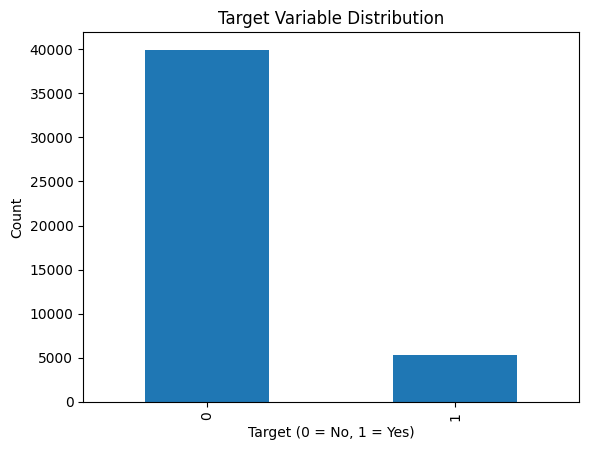

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Target variable distribution
# -------------------------------

# This is for the Count of subscription outcomes
df["target"].value_counts()

plt.figure()
# Using Bar plot to show class imbalance
df["target"].value_counts().plot(kind="bar")
plt.xlabel("Target (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Target Variable Distribution")
plt.show()


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


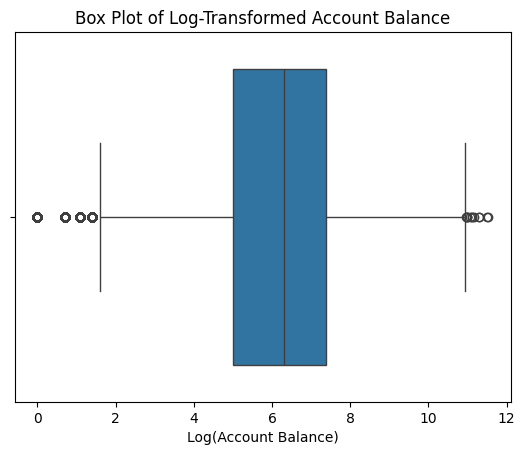

In [ ]:
# -------------------------------
# 3. Box plot for outliers (Balance)
# -------------------------------

# I created a box plot to check outliers in balance

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
# I applied log transformation to balance (add 1 to avoid log(0))
sns.boxplot(x=np.log1p(df["balance"]))
plt.xlabel("Log(Account Balance)")
plt.title("Box Plot of Log-Transformed Account Balance")
plt.show()


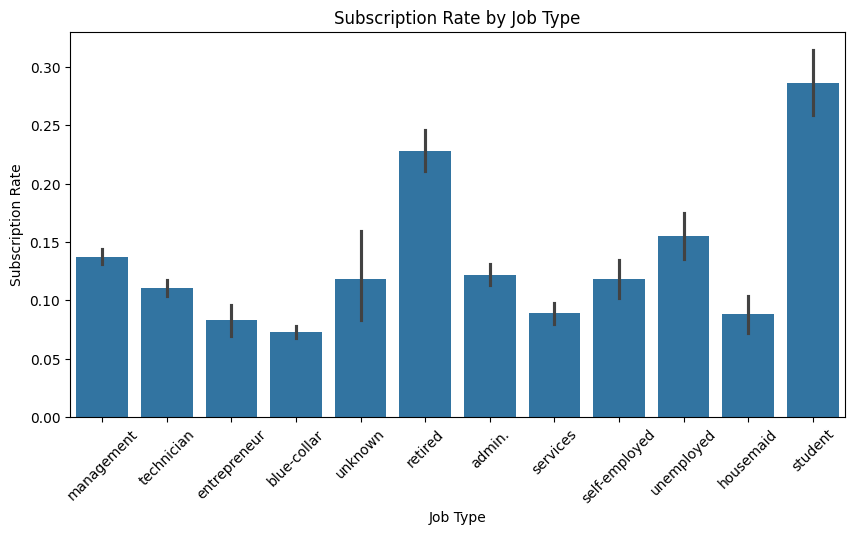

In [ ]:
# -------------------------------
# 4. Job type vs subscription rate
# -------------------------------

plt.figure(figsize=(10,5))
# I created a bar plot to compare subscription rate by job
sns.barplot(
    x="job_type",
    y="target",
    data=df,
    estimator=lambda x: sum(x) / len(x)
)
plt.xticks(rotation=45)
plt.xlabel("Job Type")
plt.ylabel("Subscription Rate")
plt.title("Subscription Rate by Job Type")
plt.show()

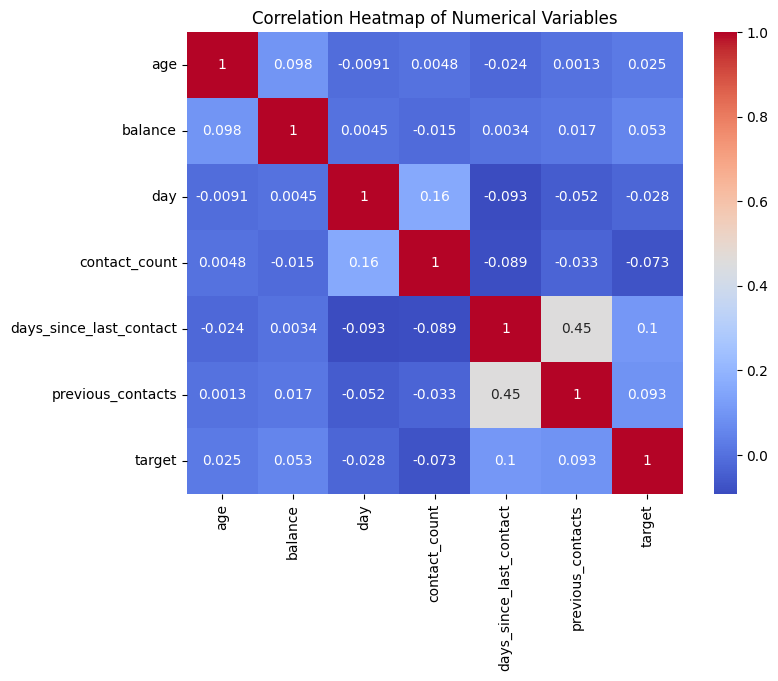

In [ ]:
# -------------------------------
# 5. Correlation heatmap
# -------------------------------

plt.figure(figsize=(8,6))
# I Selected only numerical columns for correlation
numeric_cols = df.select_dtypes(include=["int64", "float64"])

# I created a correlation heatmap to see relationships
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [ ]:
# ------------------------------------------------
# I imported required libraries
# ------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# ------------------------------------------------
# I Separated features and target
# ------------------------------------------------

X = df.drop("target", axis=1)   # Features
y = df["target"]               # Target variable



In [ ]:
# ------------------------------------------------
# Label encoding for categorical variables
# ------------------------------------------------

# I Identified categorical columns
categorical_cols = X.select_dtypes(include="object").columns

# I Applied LabelEncoder to each categorical column
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le   # Store encoder for future use


In [ ]:
# ------------------------------------------------
# Train-test split (stratified)
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # Preserve class imbalance
)


In [ ]:
# ------------------------------------------------
# Standard scaling for numerical features
# ------------------------------------------------

# I identified numerical columns
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# I Initialized scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


In [ ]:
# ------------------------------------------------
# Apply SMOTE to handle class imbalance
# ------------------------------------------------

# Initialized SMOTE
smote = SMOTE(random_state=42)

# I Applied SMOTE only on training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [ ]:
# ------------------------------------------------
# Check class distribution after SMOTE
# ------------------------------------------------

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


Before SMOTE:
target
0    31937
1     4231
Name: count, dtype: int64

After SMOTE:
target
0    31937
1    31937
Name: count, dtype: int64


In [ ]:
# ------------------------------------------------
# Decision Tree Model
# ------------------------------------------------

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# I initialized Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Training the model
dt_model.fit(X_train_smote, y_train_smote)

# I did Predicting on test data
dt_predictions = dt_model.predict(X_test)

# I did Model evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))
print("\nDecision Tree Classification Report:\n")
print(classification_report(y_test, dt_predictions))

Decision Tree Accuracy: 0.823620479929227

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.89      0.90      7985
           1       0.29      0.34      0.31      1058

    accuracy                           0.82      9043
   macro avg       0.60      0.62      0.61      9043
weighted avg       0.84      0.82      0.83      9043



In [ ]:
# ------------------------------------------------
# Tuned Naive Bayes Model
# ------------------------------------------------

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# I Initialized Naive Bayes with variance smoothing
nb_model = GaussianNB(
    var_smoothing=1e-8  # Helps stabilize variance estimates
)

# I Trained the model
nb_model.fit(X_train_smote, y_train_smote)

# I Predict on test data
nb_predictions = nb_model.predict(X_test)

# Model evaluation
print("Naive Bayes Accuracy (Tuned):", accuracy_score(y_test, nb_predictions))
print("\nNaive Bayes Classification Report (Tuned):\n")
print(classification_report(y_test, nb_predictions))


Naive Bayes Accuracy (Tuned): 0.5469423863762026

Naive Bayes Classification Report (Tuned):

              precision    recall  f1-score   support

           0       0.95      0.51      0.67      7985
           1       0.18      0.79      0.29      1058

    accuracy                           0.55      9043
   macro avg       0.56      0.65      0.48      9043
weighted avg       0.86      0.55      0.62      9043



In [ ]:
# ------------------------------------------------
# XGBoost Model
# ------------------------------------------------

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# I Initialized XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=200,        # Number of boosting trees
    max_depth=5,             # Controls tree complexity
    learning_rate=0.1,       # Step size shrinkage
    subsample=0.8,           # Row sampling
    colsample_bytree=0.8,    # Feature sampling
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

# I Trained the model on SMOTE-balanced training data
xgb_model.fit(X_train_smote, y_train_smote)

# Predict on test data
xgb_predictions = xgb_model.predict(X_test)

# Model evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_predictions))
print("\nXGBoost Classification Report:\n")
print(classification_report(y_test, xgb_predictions))


XGBoost Accuracy: 0.8941722879575362

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7985
           1       0.59      0.31      0.40      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.64      0.67      9043
weighted avg       0.88      0.89      0.88      9043



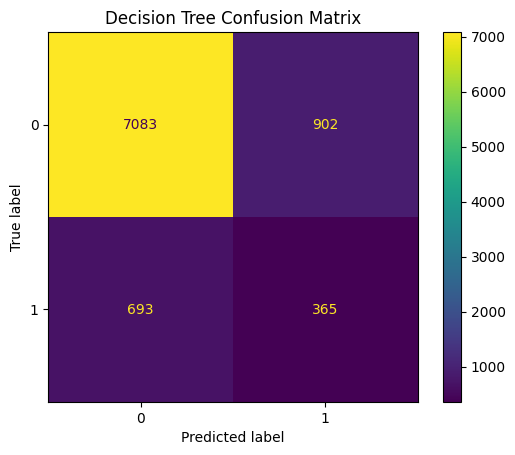

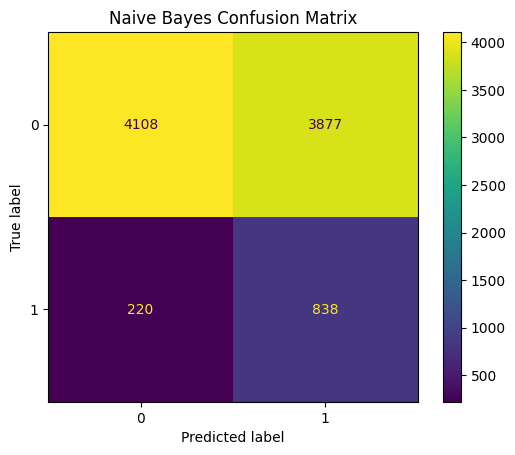

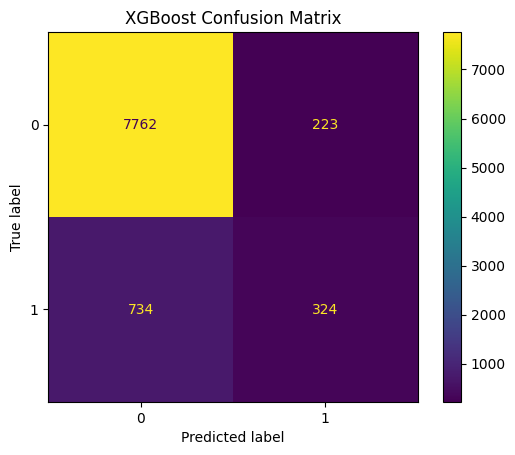

In [ ]:
# ------------------------------------------------
# Confusion Matrices
# ------------------------------------------------

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm_dt = confusion_matrix(y_test, dt_predictions)

disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

cm_nb = confusion_matrix(y_test, nb_predictions)

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp_nb.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

cm_xgb = confusion_matrix(y_test, xgb_predictions)

disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

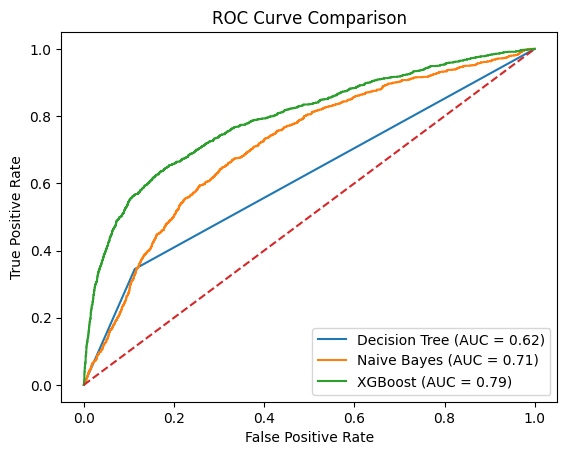

In [ ]:
# ------------------------------------------------
# ROC Curve Comparison
# ------------------------------------------------

from sklearn.metrics import roc_curve, auc

# For finding the probability scores
dt_probs = dt_model.predict_proba(X_test)[:, 1]
nb_probs = nb_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# for Computing ROC curves
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

# for Computing AUC
auc_dt = auc(fpr_dt, tpr_dt)
auc_nb = auc(fpr_nb, tpr_nb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# I have Plotted ROC curves
plt.figure()
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})")

# For Diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


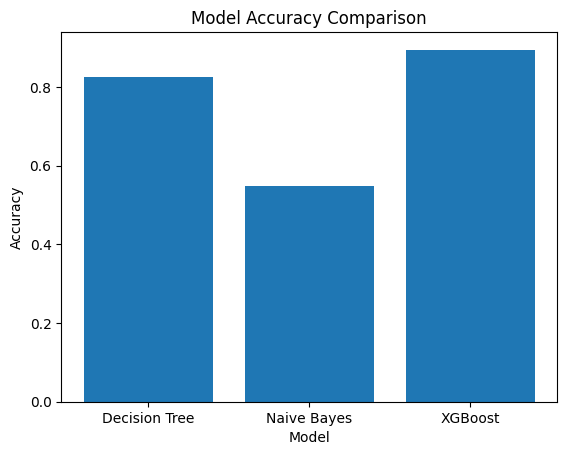

In [ ]:
# ------------------------------------------------
# Model Accuracy Comparison
# ------------------------------------------------

from sklearn.metrics import accuracy_score

# For Calculating the accuracies
accuracies = {
    "Decision Tree": accuracy_score(y_test, dt_predictions),
    "Naive Bayes": accuracy_score(y_test, nb_predictions),
    "XGBoost": accuracy_score(y_test, xgb_predictions)
}

# I have Plotted accuracy comparison
plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


In [ ]:
# ------------------------------------------------
# Hyperparameter Tuning: Decision Tree (GridSearchCV)
# ------------------------------------------------

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

# Pipeline: SMOTE is applied only on training folds inside CV
dt_pipe = Pipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Taking the Parameter grid for Decision Tree
dt_param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__criterion": ["gini", "entropy"]
}

# Using Stratified CV keeps class balance in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Using Grid search
dt_grid = GridSearchCV(
    estimator=dt_pipe,
    param_grid=dt_param_grid,
    scoring="f1",       # This f1 usage is better for imbalanced classification than accuracy
    cv=cv,
    n_jobs=-1
)

# I used to Fit on training data (NO manual SMOTE here)
dt_grid.fit(X_train, y_train)

# For the best results the parameters making the best model
best_dt = dt_grid.best_estimator_
print("Best Decision Tree Params:", dt_grid.best_params_)
print("Best CV F1 Score:", dt_grid.best_score_)

# Evaluating the test data
dt_best_pred = best_dt.predict(X_test)
print("\nDecision Tree Test Accuracy:", accuracy_score(y_test, dt_best_pred))
print("\nDecision Tree Test Report:\n", classification_report(y_test, dt_best_pred))


Best Decision Tree Params: {'model__criterion': 'entropy', 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}
Best CV F1 Score: 0.3723477437179284

Decision Tree Test Accuracy: 0.8539201592391905

Decision Tree Test Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92      7985
           1       0.37      0.36      0.37      1058

    accuracy                           0.85      9043
   macro avg       0.64      0.64      0.64      9043
weighted avg       0.85      0.85      0.85      9043



In [ ]:
# ------------------------------------------------
# Hyperparameter Tuning: Naive Bayes (GridSearchCV)
# ------------------------------------------------

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
import numpy as np

# Pipeline: SMOTE + Naive Bayes
nb_pipe = Pipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", GaussianNB())
])

# for var_smoothing values (log scale) for tuning
nb_param_grid = {
    "model__var_smoothing": np.logspace(-12, -6, 7)
}

# Using the Grid search
nb_grid = GridSearchCV(
    estimator=nb_pipe,
    param_grid=nb_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

# Using fit on training data
nb_grid.fit(X_train, y_train)

# # For the best results the parameters making the best model
best_nb = nb_grid.best_estimator_
print("Best Naive Bayes Params:", nb_grid.best_params_)
print("Best CV F1 Score:", nb_grid.best_score_)

# Evaluating the test data
nb_best_pred = best_nb.predict(X_test)
print("\nNaive Bayes Test Accuracy:", accuracy_score(y_test, nb_best_pred))
print("\nNaive Bayes Test Report:\n", classification_report(y_test, nb_best_pred))


Best Naive Bayes Params: {'model__var_smoothing': np.float64(1e-12)}
Best CV F1 Score: 0.28710924538988386

Naive Bayes Test Accuracy: 0.5469423863762026

Naive Bayes Test Report:
               precision    recall  f1-score   support

           0       0.95      0.51      0.67      7985
           1       0.18      0.79      0.29      1058

    accuracy                           0.55      9043
   macro avg       0.56      0.65      0.48      9043
weighted avg       0.86      0.55      0.62      9043



In [ ]:
# ------------------------------------------------
# Hyperparameter Tuning: XGBoost (RandomizedSearchCV)
# ------------------------------------------------

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Pipeline: SMOTE + XGBoost
xgb_pipe = Pipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

# Giving the Parameter distribution for Randomized Search
xgb_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.2, 0.3],
    "model__reg_lambda": [1, 2, 5, 10]
}

# Using Randomized search (faster than full GridSearch for XGBoost)
xgb_random = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_param_dist,
    n_iter=30,        # For showing the Number of random combinations tested
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

# Using the fit on training data
xgb_random.fit(X_train, y_train)

# # For best results the parameters making the best model
best_xgb = xgb_random.best_estimator_
print("Best XGBoost Params:", xgb_random.best_params_)
print("Best CV F1 Score:", xgb_random.best_score_)

# Evaluating on test data
xgb_best_pred = best_xgb.predict(X_test)
print("\nXGBoost Test Accuracy:", accuracy_score(y_test, xgb_best_pred))
print("\nXGBoost Test Report:\n", classification_report(y_test, xgb_best_pred))


Best XGBoost Params: {'model__subsample': 1.0, 'model__reg_lambda': 5, 'model__n_estimators': 100, 'model__min_child_weight': 7, 'model__max_depth': 8, 'model__learning_rate': 0.05, 'model__gamma': 0.2, 'model__colsample_bytree': 0.9}
Best CV F1 Score: 0.42989506343245987

XGBoost Test Accuracy: 0.8899701426517749

XGBoost Test Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94      7985
           1       0.54      0.38      0.45      1058

    accuracy                           0.89      9043
   macro avg       0.73      0.67      0.69      9043
weighted avg       0.88      0.89      0.88      9043

